## Mathematical Pendulum
An idealised mathematical pendulum consists of point mass suspended from a massless string. When the mass is deflected from its equilibrium position, it describes an oscillatory motion with a (constant) period.

We investigate how the period of a mathematical pendulum depends on the length of the string with the goal to suggest and verify a mathematical model.

### Measured data

For different lengths $L$ of the pendulum, the time $t$ for $N$ periods was measured. To reduce the likelihood of human errors, two trials were done for each length. The period is calculated as
$T = \frac{t}{N}$

The uncertainties for length and time are estimated based on the measurements.

In [14]:
import numpy as np

# length in cm
L = np.array([53.7, 46.8, 71.0, 24.8, 39.7, 87.1, 63.5, 93.9, 19.2, 31.6]) # enter your measured lengths here
dL = 1 # estimate length uncertainty in cm

# number of periods
N = np.array([10, 9, 10, 10, 10, 10, 10, 10, 10, 10]) # enter the number of periods you measured for each length here

# time for N periods in seconds
t1 = np.array([14.94, 12.53, 17.00, 10.19, 12.81, 18.93, 16.12, 19.55, 9.01, 11.43]) # enter your measured times here
t2 = np.array([14.81, 12.53, 17.06, 10.19, 12.93, 18.91, 16.22, 19.61, 9.03, 11.44]) # enter your measured times here
t = (t1 + t2) / 2 # average time for N periods in seconds
T = t / N # period in seconds

dt = 0.2 # estimate time uncertainty in seconds
dT = dt / N # period uncertainty in seconds

### Analysis

#### Period vs. length

The graph for the period $T$ vs. length is displayed in the diagram below. The error bars are too small to be seen. The relation is clearly non-linear. Possible relations are:
* square: $T =k \cdot L^2$
* square root: $T = k \cdot \sqrt L$
* …

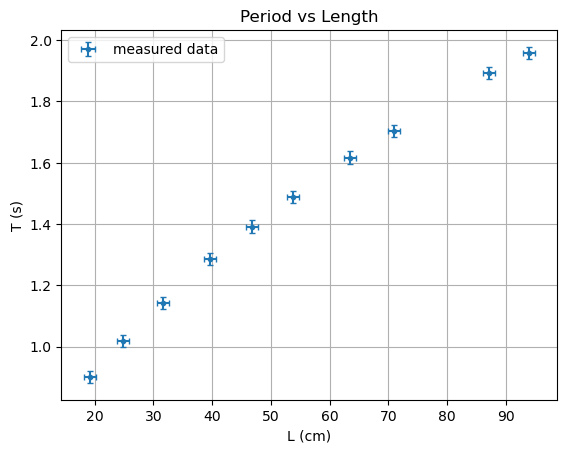

In [15]:
import matplotlib.pyplot as plt

L_range = np.linspace(0, max(L), 100) # create a range of L values for plotting the fit functions

fig, ax = plt.subplots() # create a figure and axis for plotting

# plot the measured data with error bars
ax.errorbar(L, T, xerr=dL, yerr=dT, fmt='.', capsize=2, label='measured data')

ax.set_title('Period vs Length') # set the title of the plot
ax.set_xlabel('L (cm)') # set the x-axis label
ax.set_ylabel('T (s)') # set the y-axis label
ax.grid(True) # add a grid to the plot
ax.legend() # add a legend to the plot

# use one of the following lines to display or save the plot:
plt.show()
# plt.savefig('period_vs_length.png') # save the plot as a PNG file
# plt.savefig('period_vs_length.pdf') # save the plot as a PDF file

#### Fit functions
We calculate the fit parameters for the suggested models using [scipy.optimize.curve_fit()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

In [16]:
from scipy.optimize import curve_fit

# define candidate fit functions

def fit1(x, a, b, c):
    return a * x**2 + b * x + c

def fit2(x, k):
    return k * np.sqrt(x)

def fit3(x, a, b):
    return a * x + b

# perform the fits and extract the parameters and their uncertainties
coeff1, pcov1 = curve_fit(fit1, L, T)
a, b, c = coeff1
da, db, dc = np.sqrt(np.diag(pcov1))

coeff2, pcov2 = curve_fit(fit2, L, T)
k2, = coeff2
dk2, = np.sqrt(np.diag(pcov2))

coeff3, pcov3 = curve_fit(fit3, L, T)
a3, b3, = coeff3
da3, db3 = np.sqrt(np.diag(pcov3))

# print the fit parameters and their uncertainties
print(f"Fit 1: a = {a:.5f} ± {da:.5f}, b = {b:.5f} ± {db:.5f}, c = {c:.5f} ± {dc:.5f}")
print(f"Fit 2: k = {k2:.5f} ± {dk2:.5f}")
print(f"Fit 1: a = {a3:.5f} ± {da3:.5f}, b = {b3:.5f} ± {db3:.5f}")

Fit 1: a = -0.00007 ± 0.00001, b = 0.02176 ± 0.00062, c = 0.52023 ± 0.01545
Fit 2: k = 0.20300 ± 0.00031
Fit 1: a = 0.01394 ± 0.00054, b = 0.69972 ± 0.03133


Plotting the fit functions into the data points allows for a visual confirmation. 

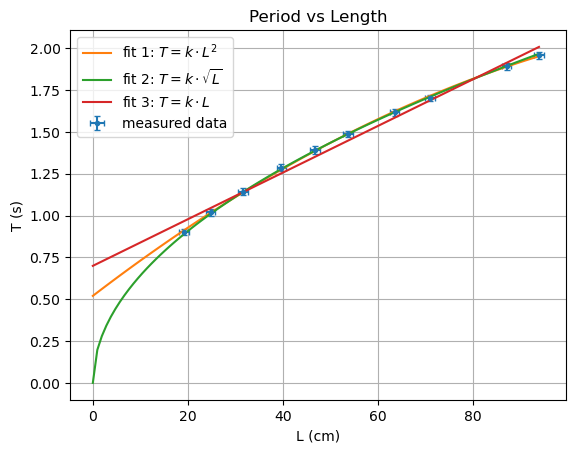

In [19]:
# create a range of L values for plotting the fit functions
L_range = np.linspace(0, max(L), 100)

# calculate the fit values for the range of L values using the parameters obtained from the fits
T_fit1 = fit1(L_range, a, b, c)
T_fit2 = fit2(L_range, k2)
T_fit3 = fit3(L_range, a3, b3)

fig, ax = plt.subplots() # create a new figure and axis for plotting the data and fits

# plot the measured data with error bars and the fit functions
ax.errorbar(L, T, xerr=dL, yerr=dT, fmt='.', capsize=2, label='measured data')
ax.plot(L_range, T_fit1, label='fit 1: '+r'$T = k \cdot L^2$')
ax.plot(L_range, T_fit2, label='fit 2: '+r'$T = k \cdot \sqrt{L}$')
ax.plot(L_range, T_fit3, label='fit 3: '+r'$T = k \cdot L$')
ax.set_title('Period vs Length')
ax.set_xlabel('L (cm)')
ax.set_ylabel('T (s)')
ax.grid(True)
ax.legend()
plt.show()

#### Residual Plot
We calculate the residuals and add a residual plot.

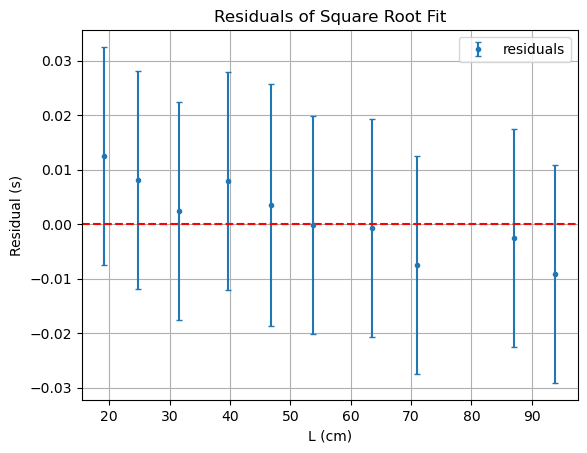

In [25]:
# calculate the residuals for the second fit
residuals = T - fit2(L, k2)

# plot the residuals with error bars
fig, ax = plt.subplots()
ax.errorbar(L, residuals, yerr=dT, fmt='.', capsize=2, label='residuals')
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuals of Square Root Fit')
ax.set_xlabel('L (cm)')
ax.set_ylabel('Residual (s)')
ax.grid(True)
ax.legend()
plt.show()

### Discussion of Results